# Model for finding and identifying brain tumor

The following project is an implementation of a convolutional neural network, which is able to identify if a patient has a brain tumor and what kind by given picture from nuclear magnetic resonance.

Loading dependencies:

In [22]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

Helper functions for the two used activation functions and their derivatives:

In [23]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def softmax_derivative(x):
    return x * (1 - x)

Class, representing convolutional layer. The class accepts as parameters in its constructor the number of filters and their size, what activation function to be used, as well as lambda constant, needed for the regularization. For the initialization of the weights is used He initialization. In order to prevent overfitting, L2 regularization is used during updating of the weights as part of the backpropagation. The idea behind this layer is to reduce the dimensions and extract only the important characteristics from the image.

In [24]:
class ConvolutionalLayer:
    def __init__(self, filters, kernel_size, activation_function, derivative_activation_function, reg_lambda=0.01):
        self.filters = filters
        self.kernel_size = kernel_size
        self.weights = np.random.randn(filters, kernel_size, kernel_size) * np.sqrt(2. / (kernel_size * kernel_size))
        self.activation_function = activation_function
        self.derivative_activation_function = derivative_activation_function
        self.reg_lambda = reg_lambda

    def calculate_output(self, input_data):
        self.input_data = input_data
        output_dim = (input_data.shape[0] - self.kernel_size) + 1
        self.output_data = np.zeros((self.filters, output_dim, output_dim))

        for f in range(self.filters):
            for i in range(output_dim):
                for j in range(output_dim):
                    region = input_data[i:i + self.kernel_size, j:j + self.kernel_size]
                    self.output_data[f, i, j] = np.sum(region * self.weights[f])

        self.output_data = self.activation_function(self.output_data)
        return self.output_data

    def backpropagate_error(self, error, learning_rate):
        derivative = self.derivative_activation_function(self.output_data)
        gradient = error * derivative
        
        d_input = np.zeros_like(self.input_data, dtype=np.float32)
        d_weights = np.zeros_like(self.weights, dtype=np.float32)

        for f in range(self.filters):
            for i in range(error.shape[0]):
                for j in range(error.shape[1]):
                    region = self.input_data[i:i + self.kernel_size, j:j + self.kernel_size]
                    d_weights[f] += region * gradient[f, i, j]

                    flipped_weights = np.flip(self.weights[f])
                    d_input[i:i + self.kernel_size, j:j + self.kernel_size] += flipped_weights * gradient[f, i, j]

        self.weights -= learning_rate * (d_weights + self.reg_lambda * self.weights)

        return d_input

Class representing pooling layer. The class accepts as parameters in its constructor the size of the stride and its offset. This layer implements max pooling, which aims to additionally reduce the dimensions and remove parts of the noise. During backpropagation, if multiple cells in a region have value, equal to the maximum value, the error is propagated to all of them. 

In [25]:
class MaxPoolingLayer:
    def __init__(self, pool_size, stride):
        self.pool_size = pool_size
        self.stride = stride

    def calculate_output(self, input_data):
        self.input_data = input_data
        output_dim = (input_data.shape[1] - self.pool_size) // self.stride + 1
        self.output_data = np.zeros((input_data.shape[0], output_dim, output_dim))

        for f in range(input_data.shape[0]):
            for i in range(output_dim):
                for j in range(output_dim):
                    start_i = i * self.stride
                    start_j = j * self.stride
                    end_i = start_i + self.pool_size
                    end_j = start_j + self.pool_size

                    region = input_data[f, start_i:end_i, start_j:end_j]
                    self.output_data[f, i, j] = np.max(region)

        return self.output_data

    def backpropagate_error(self, error, learning_rate=0):
        d_input = np.zeros_like(self.input_data, dtype=np.float32)

        for f in range(error.shape[0]):
            for i in range(error.shape[1]):
                for j in range(error.shape[2]):
                    start_i = i * self.stride
                    start_j = j * self.stride
                    end_i = start_i + self.pool_size
                    end_j = start_j + self.pool_size

                    region = self.input_data[f, start_i:end_i, start_j:end_j]
                    max_value = np.max(region)

                    for x in range(region.shape[0]):
                        for y in range(region.shape[1]):
                            if region[x, y] == max_value:
                                d_input[f, start_i + x, start_j + y] += error[f, i, j]

        return d_input

Class representing flattening layer. The idea behind it is to flatten the output of the pooling layer, so that from array of matrices it becomes a single vector, which can be easily processed from the fully-connected layer.

In [26]:
class FlattenLayer:
    def calculate_output(self, input_data):
        self.input_shape = input_data.shape
        return input_data.flatten().reshape(1, -1)

    def backpropagate_error(self, error, learning_rate=0):
        return error.reshape(self.input_shape)

Class representing dropout layer. The idea behind it is to remove part of the data in order to prevent overfitting. It needs to be placed between two fully-connected layers in the final architecture.

In [27]:
class DropoutLayer:
    def __init__(self, rate):
        self.rate = rate

    def calculate_output(self, input_data):
        self.input_data = input_data
        self.mask = np.random.rand(*input_data.shape) > self.rate
        return input_data * self.mask

    def backpropagate_error(self, error, learning_rate=0):
        return error * self.mask

Class representing fully-connected layer. This is the layer that we usually find in the perceptron, which connects every input neuron to every output neuron. For the initialization of the weights is used normal Xavier initialization as well as L2 regularization when the weights are updated during the backpropagation. 

In [28]:
class FullyConnectedLayer:
    def __init__(self, input_size, output_size, activation_function, derivative_activation_function, reg_lambda=0.01):
        self.weights = np.random.randn(input_size, output_size) * np.sqrt(1. / input_size)
        self.bias = np.zeros((1, output_size))
        self.activation_function = activation_function
        self.derivative_activation_function = derivative_activation_function
        self.reg_lambda = reg_lambda

    def calculate_output(self, input_data):
        self.input_data = input_data
        product = np.dot(input_data, self.weights) + self.bias
        self.output_data = self.activation_function(product)

        return self.output_data

    def backpropagate_error(self, error, learning_rate):
        derivative = self.derivative_activation_function(self.output_data)
        gradient = error * derivative

        weight_gradient = np.dot(self.input_data.T, gradient)
        self.weights -= learning_rate * (weight_gradient + self.reg_lambda * self.weights)
        self.bias -= learning_rate * np.sum(gradient, axis=0, keepdims=True)

        return np.dot(gradient, self.weights.T)

Function that updates the learning rate according to the epoch. The idea behind it is to reduce the rate at fixed periods in order for the network to learn better.

In [29]:
def update_learning_rate(epoch, initial_learning_rate=0.1, decay_factor=0.75, decay_epoch=7):
    if epoch % decay_epoch == 0 and epoch != 0:
        return initial_learning_rate * decay_factor
    return initial_learning_rate

Class representing the whole convolutional neural network. The class accepts the layers as parameters to its contructor. During training, the entropy loss is computed at each epoch and the learning rate is updated accordingly.  

In [30]:
class ConvolutionalNeuralNetwork:
    def __init__(self, layers):
        self.layers = layers
        self.losses_by_epochs = []

    def train(self, training_data, targets, epochs, learning_rate):
        for epoch in range(epochs):
            total_loss = 0
            learning_rate = update_learning_rate(epoch, learning_rate)
            for x, y in zip(training_data, targets):
                output = self.forward(x)
                
                loss = -np.mean(np.sum(y * np.log(output + 1e-8), axis=1))
                total_loss += loss
                
                error = output - y
                self.backward(error, learning_rate)

            current_loss = total_loss / len(training_data)
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {current_loss}")
            self.losses_by_epochs.append(current_loss)

    def forward(self, input_data):
        for layer in self.layers:
            input_data = layer.calculate_output(input_data)
        return input_data

    def backward(self, error, learning_rate):
        for layer in reversed(self.layers):
            error = layer.backpropagate_error(error, learning_rate)

Function for resizing and normalizing the image:

In [31]:
def process_image(size):
    def process_image_inner(image, label):
        image = tf.image.resize(image, (size, size))
        image = tf.squeeze(image)
        image = tf.cast(image, tf.float32) / 255.0
        label = tf.cast(label, tf.float32)
        return image, label
    return process_image_inner

Model parameters. The original dataset can be found [here](https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data).

In [32]:
dataset_directory = "./brain-tumor-mri-data/brain-tumor-mri-dataset/"
initial_image_size = 128
batch_size = 32
epochs = 50
learning_rate = 0.02
image_size = 32

Loading training and testing datasets in proportion 80:20

In [33]:
train_dataset, test_dataset = keras.utils.image_dataset_from_directory(
        directory=dataset_directory,
        image_size=(initial_image_size, initial_image_size),
        color_mode='grayscale',
        batch_size=batch_size,
        labels="inferred",
        label_mode="categorical",
        validation_split=0.2,
        subset="both",
        seed=20,
        shuffle=True
    )

Found 7153 files belonging to 4 classes.
Using 5723 files for training.
Using 1430 files for validation.


Creation of a convolutional neural network with one convolutional layer, which has 4 filters of size 3 and using ReLU as activation function, one max pooling layer with stride size of 2 and offset 2, one flattening layer and one fully-connected layer with 900 input and 4 output parameters, using softmax as activation function:

In [34]:
cnn = ConvolutionalNeuralNetwork(layers=[
    ConvolutionalLayer(filters=4, kernel_size=3, activation_function=relu, derivative_activation_function=relu_derivative),
    MaxPoolingLayer(pool_size=2, stride=2), 
    FlattenLayer(),
    FullyConnectedLayer(input_size=900, output_size=4, activation_function=softmax, derivative_activation_function=softmax_derivative),
])

Loading 1024 training images and training the network based on them:

In [35]:
train_images = []
train_labels = []
for image, label in train_dataset.map(process_image(image_size)).shuffle(buffer_size=100).take(32).unbatch():
    train_images.append(image.numpy())
    train_labels.append(label.numpy())

cnn.train(train_images, train_labels, epochs=epochs, learning_rate=learning_rate)

2025-05-03 00:05:18.133370: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1/50, Loss: 1.2162754149012374
Epoch 2/50, Loss: 1.0471801372515814
Epoch 3/50, Loss: 0.9734398621222159
Epoch 4/50, Loss: 0.932378239141859
Epoch 5/50, Loss: 0.9063128909977655
Epoch 6/50, Loss: 0.8880210859216734
Epoch 7/50, Loss: 0.8741704564383507
Epoch 8/50, Loss: 0.8407118128502287
Epoch 9/50, Loss: 0.8316846315577752
Epoch 10/50, Loss: 0.8245834791527339
Epoch 11/50, Loss: 0.8185303248457719
Epoch 12/50, Loss: 0.8132300931758677
Epoch 13/50, Loss: 0.8084650064335657
Epoch 14/50, Loss: 0.80412221367998
Epoch 15/50, Loss: 0.7782926846865511
Epoch 16/50, Loss: 0.7739283018759688
Epoch 17/50, Loss: 0.7704856885466136
Epoch 18/50, Loss: 0.7674179811909119
Epoch 19/50, Loss: 0.7646159251533334
Epoch 20/50, Loss: 0.7620393429928685
Epoch 21/50, Loss: 0.7596531280708001
Epoch 22/50, Loss: 0.7393146904269725
Epoch 23/50, Loss: 0.7363277924669964
Epoch 24/50, Loss: 0.7340622554338443
Epoch 25/50, Loss: 0.7320069298304746
Epoch 26/50, Loss: 0.7301083120978363
Epoch 27/50, Loss: 0.728

Loading 256 testing images and computing the accuracy of the model according to them:

In [40]:
test_images = []
test_labels = []
for image, label in test_dataset.map(process_image(image_size)).shuffle(buffer_size=100).take(8).unbatch():
    test_images.append(image.numpy())
    test_labels.append(label.numpy())

test_images = np.array(test_images)
test_labels = np.array(test_labels)
    
predictions = []
for image in test_images:
    predictions.append(np.argmax(cnn.forward(image), axis=1)[0])
labels = np.argmax(test_labels, axis=1)
predictions = np.array(predictions)

accuracy = 0
for pred, true_label in zip(predictions, labels):
    if pred == true_label:
        accuracy += 1

accuracy = accuracy / len(labels)
print(f"Finished with accuracy of {accuracy * 100}%")

Finished with accuracy of 76.82926829268293%


Graphic of the entropy loss during training:

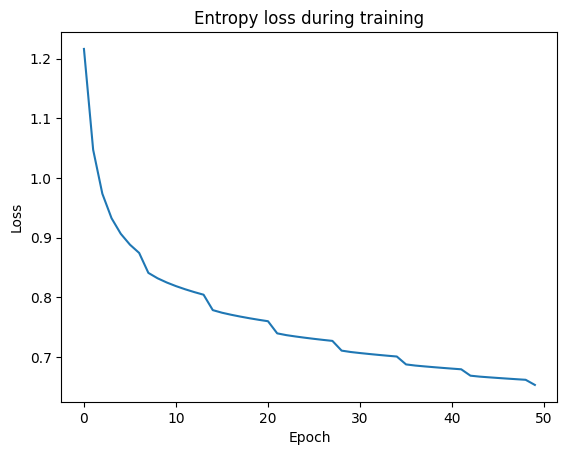

In [41]:
plt.plot(range(epochs), cnn.losses_by_epochs)
plt.title("Entropy loss during training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Some example results:

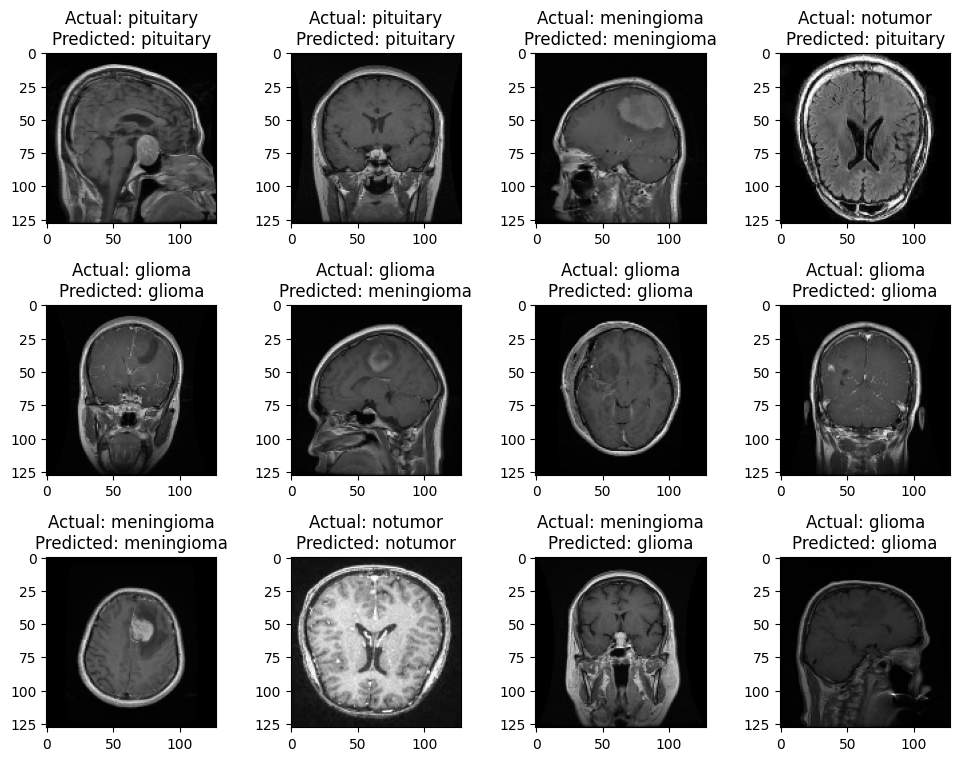

In [42]:
plt.figure(figsize=(10, 10))

for i, (image, label) in enumerate(test_dataset.shuffle(buffer_size=100).take(1).unbatch().take(12)):
    actual_label = train_dataset.class_names[np.argmax(label)]
    image = image.numpy()
                
    plt.subplot(4, 4, i + 1)
    plt.imshow(image, cmap="gray")
        
    processed_image, _ = process_image(image_size)(image, label)
    predictions = cnn.forward(processed_image)
    prediction = np.argmax(predictions[0])
        
    if prediction == 0:
        predicted_label = 'glioma'
    elif prediction == 1:
        predicted_label = 'meningioma'
    elif prediction == 2:
        predicted_label = 'notumor'
    elif prediction == 3:
        predicted_label ='pituitary'
        
    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
    plt.tight_layout()